In [174]:
# Environment setup (uncomment on Colab)
# !pip install -Uqq fastbook

# === Core imports ===

# fastai collaborative filtering tools
from fastai.collab import CollabDataLoaders, collab_learner
from fastai.tabular.all import (
    Embedding,       # nn.Embedding wrapper — lookup table for learnable vectors
    Module,          # fastai's nn.Module wrapper (auto-moves params to GPU)
    Learner,         # training loop: handles forward, loss, backward, update
    MSELossFlat,     # Mean Squared Error loss, flattened for batched predictions
    sigmoid_range,   # squishes any number into a (low, high) range using sigmoid
)

# PyTorch
import torch
import torch.nn as nn

# Data
import pandas as pd
import numpy as np

# Utilities
from fastcore.foundation import L              # fastai's enhanced list
from fastai.data.transforms import untar_data, URLs  # dataset downloading
from fastai.torch_core import one_hot          # creates one-hot encoded vectors
from fastai.tabular.model import get_emb_sz    # recommends embedding sizes

print("All imports loaded!")

All imports loaded!


All imports are in the cell above — no wildcard imports needed. This keeps it clear where every function comes from.

# Collaborative Filtering Deep Dive

One very common problem to solve is when you have a number of users and a number of products, and you want to recommend which products are most likely to be useful for which users. There are many variations of this: for example, recommending movies (such as on Netflix), figuring out what to highlight for a user on a home page, deciding what stories to show in a social media feed, and so forth. There is a general solution to this problem, called *collaborative filtering*, which works like this: look at what products the current user has used or liked, find other users that have used or liked similar products, and then recommend other products that those users have used or liked.

For example, on Netflix you may have watched lots of movies that are science fiction, full of action, and were made in the 1970s. Netflix may not know these particular properties of the films you have watched, but it will be able to see that other people that have watched the same movies that you watched also tended to watch other movies that are science fiction, full of action, and were made in the 1970s. In other words, to use this approach we don't necessarily need to know anything about the movies, except who like to watch them.

There is actually a more general class of problems that this approach can solve, not necessarily involving users and products. Indeed, for collaborative filtering we more commonly refer to *items*, rather than *products*. Items could be links that people click on, diagnoses that are selected for patients, and so forth.

The key foundational idea is that of *latent factors*. In the Netflix example, we started with the assumption that you like old, action-packed sci-fi movies. But you never actually told Netflix that you like these kinds of movies. And Netflix never actually needed to add columns to its movies table saying which movies are of these types. Still, there must be some underlying concept of sci-fi, action, and movie age, and these concepts must be relevant for at least some people's movie watching decisions.

For this chapter we are going to work on this movie recommendation problem. We'll start by getting some data suitable for a collaborative filtering model.

## A First Look at the Data

We do not have access to Netflix's entire dataset of movie watching history, but there is a great dataset that we can use, called [MovieLens](https://grouplens.org/datasets/movielens/). This dataset contains tens of millions of movie rankings (a combination of a movie ID, a user ID, and a numeric rating), although we will just use a subset of 100,000 of them for our example. If you're interested, it would be a great learning project to try and replicate this approach on the full 25-million recommendation dataset, which you can get from their website.

The dataset is available through the usual fastai function:

In [175]:
# Download the MovieLens 100K dataset (100,000 ratings from 943 users on 1,682 movies)
path = untar_data(URLs.ML_100k)
path.ls()  # see what files we got

(#23) [Path('/data/cache/fastai/data/ml-100k/u4.test'),Path('/data/cache/fastai/data/ml-100k/u1.test'),Path('/data/cache/fastai/data/ml-100k/ub.base'),Path('/data/cache/fastai/data/ml-100k/ua.base'),Path('/data/cache/fastai/data/ml-100k/u.info'),Path('/data/cache/fastai/data/ml-100k/README'),Path('/data/cache/fastai/data/ml-100k/u.data'),Path('/data/cache/fastai/data/ml-100k/u3.test'),Path('/data/cache/fastai/data/ml-100k/u.occupation'),Path('/data/cache/fastai/data/ml-100k/u3.base'),Path('/data/cache/fastai/data/ml-100k/u2.test'),Path('/data/cache/fastai/data/ml-100k/u1.base'),Path('/data/cache/fastai/data/ml-100k/u.user'),Path('/data/cache/fastai/data/ml-100k/u.item'),Path('/data/cache/fastai/data/ml-100k/ub.test'),Path('/data/cache/fastai/data/ml-100k/u5.test'),Path('/data/cache/fastai/data/ml-100k/u4.base'),Path('/data/cache/fastai/data/ml-100k/allbut.pl'),Path('/data/cache/fastai/data/ml-100k/mku.sh'),Path('/data/cache/fastai/data/ml-100k/u5.base'),Path('/data/cache/fastai/data/ml

According to the *README*, the main table is in the file *u.data*. It is tab-separated and the columns are, respectively user, movie, rating, and timestamp. Since those names are not encoded, we need to indicate them when reading the file with Pandas. Here is a way to open this table and take a look:

In [176]:
# The raw data is tab-separated with no header row
# Columns: user ID, movie ID, rating (1-5), unix timestamp
ratings = pd.read_csv(
    path/'u.data',
    delimiter='\t',     # tab-separated, not comma
    header=None,         # no column names in the file
    names=['user', 'movie', 'rating', 'timestamp']
)
ratings.head()

,user,movie,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


Although this has all the information we need, it is not a particularly helpful way for humans to look at this data.  shows the same data cross-tabulated into a human-friendly table.

<img alt="Crosstab of movies and users" width="632" caption="Crosstab of movies and users" id="movie_xtab" src="images/att_00040.png">

We have selected just a few of the most popular movies, and users who watch the most movies, for this crosstab example. The empty cells in this table are the things that we would like our model to learn to fill in. Those are the places where a user has not reviewed the movie yet, presumably because they have not watched it. For each user, we would like to figure out which of those movies they might be most likely to enjoy.

If we knew for each user to what degree they liked each important category that a movie might fall into, such as genre, age, preferred directors and actors, and so forth, and we knew the same information about each movie, then a simple way to fill in this table would be to multiply this information together for each movie and use a combination. For instance, assuming these factors range between -1 and +1, with positive numbers indicating stronger matches and negative numbers weaker ones, and the categories are science-fiction, action, and old movies, then we could represent the movie *The Last Skywalker* as:

In [177]:
# Imagine we KNEW what qualities matter for movies.
# Let's say 3 factors: [sci-fi, action, modern]
# Last Skywalker: very sci-fi (0.98), very action (0.9), very modern (-0.9 = not old)
last_skywalker = np.array([0.98, 0.9, -0.9])

Here, for instance, we are scoring *very science-fiction* as 0.98, *very action* as 0.9, and *very not old* as -0.9. We could represent a user who likes modern sci-fi action movies as:

In [178]:
# A user who loves modern sci-fi action movies
# High sci-fi preference (0.9), high action (0.8), prefers modern (-0.6)
user1 = np.array([0.9, 0.8, -0.6])

and we can now calculate the match between this combination:

In [179]:
# Dot product = element-wise multiply, then sum
# Measures how well user preferences align with movie qualities
# High positive = good match, negative = bad match
(user1 * last_skywalker).sum()

np.float64(2.1420000000000003)

When we multiply two vectors together and add up the results, this is known as the *dot product*. It is used a lot in machine learning, and forms the basis of matrix multiplication. We will be looking a lot more at matrix multiplication and dot products in .

📖 **Jargon: dot product: The mathematical operation of multiplying the elements of two vectors together, and then summing up the result.**



On the other hand, we might represent the movie *Casablanca* as:

In [180]:
# Casablanca: not sci-fi (-0.99), not action (-0.3), old/classic (0.8)
casablanca = np.array([-0.99, -0.3, 0.8])

The match between this combination is:

In [181]:
# Negative score — this user's preferences don't align with Casablanca
(user1 * casablanca).sum()

np.float64(-1.611)

Since we don't know what the latent factors actually are, and we don't know how to score them for each user and movie, we should learn them.

## Learning the Latent Factors

There is surprisingly little difference between specifying the structure of a model, as we did in the last section, and learning one, since we can just use our general gradient descent approach.

Step 1 of this approach is to randomly initialize some parameters. These parameters will be a set of latent factors for each user and movie. We will have to decide how many to use. We will discuss how to select this shortly, but for illustrative purposes let's use 5 for now. Because each user will have a set of these factors and each movie will have a set of these factors, we can show these randomly initialized values right next to the users and movies in our crosstab, and we can then fill in the dot products for each of these combinations in the middle. For example,  shows what it looks like in Microsoft Excel, with the top-left cell formula displayed as an example.

<img alt="Latent factors with crosstab" width="900" caption="Latent factors with crosstab" id="xtab_latent" src="images/att_00041.png">

Step 2 of this approach is to calculate our predictions. As we've discussed, we can do this by simply taking the dot product of each movie with each user. If, for instance, the first latent user factor represents how much the user likes action movies and the first latent movie factor represents if the movie has a lot of action or not, the product of those will be particularly high if either the user likes action movies and the movie has a lot of action in it or the user doesn't like action movies and the movie doesn't have any action in it. On the other hand, if we have a mismatch (a user loves action movies but the movie isn't an action film, or the user doesn't like action movies and it is one), the product will be very low.

Step 3 is to calculate our loss. We can use any loss function that we wish; let's pick mean squared error for now, since that is one reasonable way to represent the accuracy of a prediction.

That's all we need. With this in place, we can optimize our parameters (that is, the latent factors) using stochastic gradient descent, such as to minimize the loss. At each step, the stochastic gradient descent optimizer will calculate the match between each movie and each user using the dot product, and will compare it to the actual rating that each user gave to each movie. It will then calculate the derivative of this value and will step the weights by multiplying this by the learning rate. After doing this lots of times, the loss will get better and better, and the recommendations will also get better and better.

To use the usual `Learner.fit` function we will need to get our data into a `DataLoaders`, so let's focus on that now.

## Creating the DataLoaders

When showing the data, we would rather see movie titles than their IDs. The table `u.item` contains the correspondence of IDs to titles:

In [182]:
# u.item contains movie metadata (ID, title, date, genre, etc.)
# We only need columns 0 (ID) and 1 (title)
# encoding='latin-1' because some movie titles have special characters
movies = pd.read_csv(
    path/'u.item',
    delimiter='|',
    encoding='latin-1',
    usecols=(0, 1),
    names=('movie', 'title'),
    header=None
)
movies.head()

,movie,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


We can merge this with our `ratings` table to get the user ratings by title:

In [183]:
# Merge on the 'movie' column so we get human-readable titles
# instead of just numeric IDs
ratings = ratings.merge(movies)
ratings.head()

,user,movie,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


We can then build a `DataLoaders` object from this table. By default, it takes the first column for the user, the second column for the item (here our movies), and the third column for the ratings. We need to change the value of `item_name` in our case to use the titles instead of the IDs:

In [184]:
# CollabDataLoaders expects: column 1 = user, column 2 = item, column 3 = rating
# item_name='title' tells it to use movie titles as item identifiers
# bs=64: each training batch will contain 64 (user, movie, rating) triplets
dls = CollabDataLoaders.from_df(ratings, item_name='title', bs=64)

# show_batch displays sample (user, title, rating) rows from one batch
dls.show_batch()

,user,title,rating
0,637,Air Force One (1997),3
1,216,Swimming with Sharks (1995),5
2,653,Pump Up the Volume (1990),2
3,454,She's So Lovely (1997),1
4,11,Ransom (1996),3
5,889,Young Guns (1988),3
6,880,Four Weddings and a Funeral (1994),4
7,569,"Rock, The (1996)",3
8,886,Scream (1996),4
9,58,Citizen Kane (1941),5


We can't use the crosstab (the big user×movie grid) directly in PyTorch. Instead, we store two separate matrices — one for users, one for movies — where each row is a vector of **latent factors**. These are the numbers our model will learn.

Let's set that up manually first to see what it looks like:

In [185]:
# dls.classes shows the unique users and movies in our dataset
# These are the categories that need embeddings
dls.classes

{'user': ['#na#', np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12), np.int16(13), np.int16(14), np.int16(15), np.int16(16), np.int16(17), np.int16(18), np.int16(19), np.int16(20), np.int16(21), np.int16(22), np.int16(23), np.int16(24), np.int16(25), np.int16(26), np.int16(27), np.int16(28), np.int16(29), np.int16(30), np.int16(31), np.int16(32), np.int16(33), np.int16(34), np.int16(35), np.int16(36), np.int16(37), np.int16(38), np.int16(39), np.int16(40), np.int16(41), np.int16(42), np.int16(43), np.int16(44), np.int16(45), np.int16(46), np.int16(47), np.int16(48), np.int16(49), np.int16(50), np.int16(51), np.int16(52), np.int16(53), np.int16(54), np.int16(55), np.int16(56), np.int16(57), np.int16(58), np.int16(59), np.int16(60), np.int16(61), np.int16(62), np.int16(63), np.int16(64), np.int16(65), np.int16(66), np.int16(67), np.int16(68), np.int16(69), np.int16(70), np.int16(71

In [186]:
# Count unique users and movies
n_users  = len(dls.classes['user'])    # 943 unique users
n_movies = len(dls.classes['title'])   # 1,664 unique movies
n_factors = 5                          # 5 latent factors per user/movie (a hyperparameter)

# Create two randomly initialized matrices — these will be our learnable weights
# user_factors: shape (943, 5) — each user gets a 5-number vector
# movie_factors: shape (1664, 5) — each movie gets a 5-number vector
user_factors = torch.randn(n_users, n_factors)
movie_factors = torch.randn(n_movies, n_factors)

print(f"User matrix:  {user_factors.shape}")
print(f"Movie matrix: {movie_factors.shape}")

User matrix:  torch.Size([944, 5])
Movie matrix: torch.Size([1665, 5])


To predict a rating, we need to look up the right row in each matrix. But "look up row 3" isn't a differentiable operation — and we need differentiability for gradient descent to work.

The trick: we can express "look up row 3" as a matrix multiplication with a **one-hot encoded vector**. A one-hot vector is all zeros except for a single 1 at the index we want. Multiplying a matrix by this vector extracts exactly that row:

In [187]:
# Create a one-hot vector with 1 at position 3, zeros elsewhere
# Length = n_users (943), so it can multiply with the user_factors matrix
one_hot_3 = one_hot(3, n_users).float()
print(f"Shape: {one_hot_3.shape}")
print(f"Sum: {one_hot_3.sum()}")  # should be 1.0 — only one position is "hot"

Shape: torch.Size([944])
Sum: 1.0


In [188]:
# Matrix multiply: user_factors transposed × one_hot vector
# This extracts row 3 from user_factors
# .t() = transpose, @ = matrix multiplication
user_factors.t() @ one_hot_3

tensor([ 0.2915, -3.6647, -0.9560, -1.0293, -1.1531])

It gives us the same vector as the one at index 3 in the matrix:

In [189]:
# Same result! Direct indexing gives us the exact same vector.
# Embedding layers use this shortcut — they just index directly,
# but compute gradients as if they did the matrix multiplication.
user_factors[3]

tensor([ 0.2915, -3.6647, -0.9560, -1.0293, -1.1531])

Doing a full matrix multiplication with one-hot vectors works mathematically, but it wastes memory and time — most of the vector is zeros. PyTorch's `Embedding` layer takes the shortcut: it indexes directly with an integer, but computes gradients as if it did the full matrix multiplication. Same math, much faster.

This is all an embedding is — **a lookup table that supports gradient descent**.

📖 **Jargon: Embedding: Multiplying by a one-hot-encoded matrix, using the computational shortcut that it can be implemented by simply indexing directly. This is quite a fancy word for a very simple concept. The thing that you multiply the one-hot-encoded matrix by (or, using the computational shortcut, index into directly) is called the _embedding matrix_.**



In computer vision, we have a very easy way to get all the information of a pixel through its RGB values: each pixel in a colored image is represented by three numbers. Those three numbers give us the redness, the greenness and the blueness, which is enough to get our model to work afterward.

For the problem at hand, we don't have the same easy way to characterize a user or a movie. There are probably relations with genres: if a given user likes romance, they are likely to give higher scores to romance movies. Other factors might be whether the movie is more action-oriented versus heavy on dialogue, or the presence of a specific actor that a user might particularly like. 

How do we determine numbers to characterize those? The answer is, we don't. We will let our model *learn* them. By analyzing the existing relations between users and movies, our model can figure out itself the features that seem important or not.

This is what embeddings are. We will attribute to each of our users and each of our movies a random vector of a certain length (here, `n_factors=5`), and we will make those learnable parameters. That means that at each step, when we compute the loss by comparing our predictions to our targets, we will compute the gradients of the loss with respect to those embedding vectors and update them with the rules of SGD (or another optimizer).

At the beginning, those numbers don't mean anything since we have chosen them randomly, but by the end of training, they will. By learning on existing data about the relations between users and movies, without having any other information, we will see that they still get some important features, and can isolate blockbusters from independent cinema, action movies from romance, and so on.

We are now in a position that we can create our whole model from scratch.

## Collaborative Filtering from Scratch

Before we can write a model in PyTorch, we first need to learn the basics of object-oriented programming and Python. If you haven't done any object-oriented programming before, we will give you a quick introduction here, but we would recommend looking up a tutorial and getting some practice before moving on.

The key idea in object-oriented programming is the *class*. We have been using classes throughout this book, such as `DataLoader`, `string`, and `Learner`. Python also makes it easy for us to create new classes. Here is an example of a simple class:

In [190]:
class Example:
    def __init__(self, a): self.a = a
    def say(self,x): return f'Hello {self.a}, {x}.'

The most important piece of this is the special method called `__init__` (pronounced *dunder init*). In Python, any method surrounded in double underscores like this is considered special. It indicates that there is some extra behavior associated with this method name. In the case of `__init__`, this is the method Python will call when your new object is created. So, this is where you can set up any state that needs to be initialized upon object creation. Any parameters included when the user constructs an instance of your class will be passed to the `__init__` method as parameters. Note that the first parameter to any method defined inside a class is `self`, so you can use this to set and get any attributes that you will need:

In [191]:
ex = Example('Sylvain')
ex.say('nice to meet you')

'Hello Sylvain, nice to meet you.'

Also note that creating a new PyTorch module requires inheriting from `Module`. *Inheritance* is an important object-oriented concept that we will not discuss in detail here—in short, it means that we can add additional behavior to an existing class. PyTorch already provides a `Module` class, which provides some basic foundations that we want to build on. So, we add the name of this *superclass* after the name of the class that we are defining, as shown in the following example.

The final thing that you need to know to create a new PyTorch module is that when your module is called, PyTorch will call a method in your class called `forward`, and will pass along to that any parameters that are included in the call. Here is the class defining our dot product model:

In [192]:
class DotProduct(Module):
    def __init__(self, n_users, n_movies, n_factors):
        # Two embedding matrices — these ARE the model's learnable parameters
        self.user_factors = Embedding(n_users, n_factors)    # shape: (943, n_factors)
        self.movie_factors = Embedding(n_movies, n_factors)  # shape: (1664, n_factors)

    def forward(self, x):
        # x is a batch of (user_id, movie_id) pairs, shape: (batch_size, 2)
        users = self.user_factors(x[:, 0])   # look up each user's embedding vector
        movies = self.movie_factors(x[:, 1])  # look up each movie's embedding vector
        # Element-wise multiply then sum across factors = dot product for each pair
        # (batch_size, n_factors) * (batch_size, n_factors) → sum → (batch_size,)
        return (users * movies).sum(dim=1)

That's the **entire model**. No hidden layers, no activation functions. Just two embedding lookups and a dot product.

The input `x` is a tensor of shape `(batch_size, 2)`. Column 0 (`x[:, 0]`) contains user IDs, column 1 (`x[:, 1]`) contains movie IDs. The embedding layers convert these integer IDs into learned vectors, and the dot product measures how well each user-movie pair matches.

Let's verify the input shape:

In [193]:
# Grab one batch to inspect — should be (64, 2): 64 pairs of (user_id, movie_id)
x, y = dls.one_batch()
print(f"Input shape:  {x.shape}")   # (64, 2) — the user/movie ID pairs
print(f"Target shape: {y.shape}")   # (64,) — the actual ratings (our labels)

Input shape:  torch.Size([64, 2])
Target shape: torch.Size([64, 1])


Now we need a `Learner` to handle the training loop — forward pass, loss calculation, backward pass, weight update. Since we're building from scratch (not using a pre-built `vision_learner` or similar), we use the plain `Learner` class and specify our loss function explicitly:

In [194]:
# 50 latent factors per user and movie (richer representation than our demo with 5)
model = DotProduct(n_users, n_movies, 50)

# MSELossFlat = Mean Squared Error: (predicted_rating - actual_rating)²
# This is the standard loss for regression problems
learn = Learner(dls, model, loss_func=MSELossFlat())

Let's train for 5 epochs (5 full passes through all the rating data) with a learning rate of 0.005:

In [195]:
# fit_one_cycle: trains with a learning rate that rises then falls (1cycle policy)
# 5 = epochs, 5e-3 = max learning rate (0.005)
learn.fit_one_cycle(5, 5e-3)

epoch,train_loss,valid_loss,time


Not bad for a first try. But there's a problem: our dot product can output any number — negative, larger than 5, anything. Real ratings are between 0 and 5.

We can fix this by wrapping the output in `sigmoid_range`, which squishes any number into a specified range. We use `(0, 5.5)` instead of `(0, 5)` because sigmoid approaches but never quite reaches its bounds — using 5.5 lets the model actually predict values close to 5.0:

In [196]:
class DotProduct(Module):
    def __init__(self, n_users, n_movies, n_factors, y_range=(0, 5.5)):
        self.user_factors = Embedding(n_users, n_factors)
        self.movie_factors = Embedding(n_movies, n_factors)
        self.y_range = y_range  # valid output range for ratings

    def forward(self, x):
        users = self.user_factors(x[:, 0])
        movies = self.movie_factors(x[:, 1])
        # Same dot product as before, but now clamped to valid rating range
        return sigmoid_range((users * movies).sum(dim=1), *self.y_range)

In [197]:
model = DotProduct(n_users, n_movies, 50)
learn = Learner(dls, model, loss_func=MSELossFlat())
learn.fit_one_cycle(5, 5e-3)
# Compare the loss to the previous version — should be a bit better

Better! But we're still missing something. Think about it: some users are generous raters (they give everything 4-5 stars), while others are harsh (everything gets 2-3). And some movies are universally loved regardless of taste, while others are universally disliked.

Our dot product can only capture how well a user's taste **matches** a movie's qualities. It can't express "this user rates everything high" or "everyone likes Shawshank Redemption."

The fix: add a **bias** term — one learnable number per user and one per movie. These shift the prediction up or down:

`prediction = dot(user_vec, movie_vec) + user_bias + movie_bias`

In [198]:
class DotProductBias(Module):
    def __init__(self, n_users, n_movies, n_factors, y_range=(0, 5.5)):
        self.user_factors = Embedding(n_users, n_factors)   # (943, n_factors) — taste vectors
        self.user_bias = Embedding(n_users, 1)              # (943, 1) — one bias per user
        self.movie_factors = Embedding(n_movies, n_factors)  # (1664, n_factors) — quality vectors
        self.movie_bias = Embedding(n_movies, 1)             # (1664, 1) — one bias per movie
        self.y_range = y_range

    def forward(self, x):
        users = self.user_factors(x[:, 0])       # (batch, n_factors)
        movies = self.movie_factors(x[:, 1])      # (batch, n_factors)
        # Dot product: how well does this user's taste match this movie?
        res = (users * movies).sum(dim=1, keepdim=True)  # (batch, 1)
        # Add biases: shift prediction based on user generosity + movie quality
        res += self.user_bias(x[:, 0]) + self.movie_bias(x[:, 1])
        return sigmoid_range(res, *self.y_range)

Let's try training this and see how it goes:

In [199]:
model = DotProductBias(n_users, n_movies, 50)
learn = Learner(dls, model, loss_func=MSELossFlat())
learn.fit_one_cycle(5, 5e-3)
# Watch the valid_loss column — does it improve throughout, or start getting worse?

epoch,train_loss,valid_loss,time
0,0.894119,0.957665,00:02
1,0.592396,0.928168,00:02
2,0.398480,0.955036,00:02
3,0.319920,0.963499,00:02
4,0.299745,0.964167,00:02


Worse! Look at the validation loss — it stopped improving partway through and started climbing. Classic overfitting: the model memorizes training data instead of learning general patterns.

Why did adding biases cause overfitting? More parameters = more capacity to memorize. We went from `(943 + 1664) × 50 = 130,350` parameters to that plus `943 + 1664 = 2,607` bias terms. The biases give the model just enough extra flexibility to overfit.

We can't use data augmentation here (how would you augment a rating?), so we need a different regularization technique: **weight decay**.

### Weight Decay

Weight decay, or *L2 regularization*, consists in adding to your loss function the sum of all the weights squared. Why do that? Because when we compute the gradients, it will add a contribution to them that will encourage the weights to be as small as possible.

Why would it prevent overfitting? The idea is that the larger the coefficients are, the sharper canyons we will have in the loss function. If we take the basic example of a parabola, `y = a * (x**2)`, the larger `a` is, the more *narrow* the parabola is ().

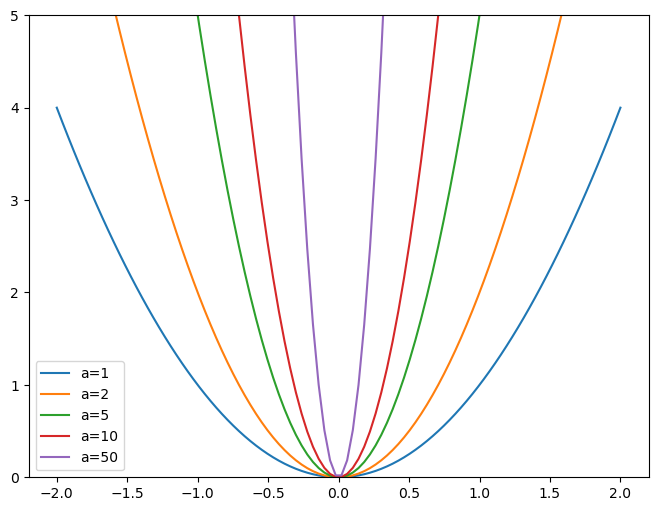

In [200]:
import matplotlib.pyplot as plt                                                                                                                                                                                  

x = np.linspace(-2,2,100)                                                                                                                                                                                        
a_s = [1,2,5,10,50]                                             
ys = [a * x**2 for a in a_s]
_,ax = plt.subplots(figsize=(8,6))
for a,y in zip(a_s,ys): ax.plot(x,y, label=f'a={a}')
ax.set_ylim([0,5])
ax.legend();

So, letting our model learn high parameters might cause it to fit all the data points in the training set with an overcomplex function that has very sharp changes, which will lead to overfitting.

Limiting our weights from growing too much is going to hinder the training of the model, but it will yield a state where it generalizes better. Going back to the theory briefly, weight decay (or just `wd`) is a parameter that controls that sum of squares we add to our loss (assuming `parameters` is a tensor of all parameters):

``` python
loss_with_wd = loss + wd * (parameters**2).sum()
```

In practice, though, it would be very inefficient (and maybe numerically unstable) to compute that big sum and add it to the loss. If you remember a little bit of high school math, you might recall that the derivative of `p**2` with respect to `p` is `2*p`, so adding that big sum to our loss is exactly the same as doing:

``` python
parameters.grad += wd * 2 * parameters
```

In practice, since `wd` is a parameter that we choose, we can just make it twice as big, so we don't even need the `*2` in this equation. To use weight decay in fastai, just pass `wd` in your call to `fit` or `fit_one_cycle`:

In [201]:
model = DotProductBias(n_users, n_movies, 50)
learn = Learner(dls, model, loss_func=MSELossFlat())
# wd=0.1 adds weight decay: penalizes large parameter values to prevent overfitting
# loss_total = MSE_loss + 0.1 * sum(all_weights²)
learn.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time
0,0.884285,0.961552,00:02
1,0.649141,0.914122,00:02
2,0.541755,0.882666,00:02
3,0.451516,0.867878,00:02
4,0.429688,0.863591,00:02


Much better!

### Creating Our Own Embedding Module

So far, we've used `Embedding` without thinking about how it really works. Let's re-create `DotProductBias` *without* using this class. We'll need a randomly initialized weight matrix for each of the embeddings. We have to be careful, however. Recall from  that optimizers require that they can get all the parameters of a module from the module's `parameters` method. However, this does not happen fully automatically. If we just add a tensor as an attribute to a `Module`, it will not be included in `parameters`:

In [202]:
class T(Module):
    def __init__(self): self.a = torch.ones(3)

L(T().parameters())

(#0) []

To tell `Module` that we want to treat a tensor as a parameter, we have to wrap it in the `nn.Parameter` class. This class doesn't actually add any functionality (other than automatically calling `requires_grad_` for us). It's only used as a "marker" to show what to include in `parameters`:

In [203]:
class T(Module):
    def __init__(self): self.a = nn.Parameter(torch.ones(3))

L(T().parameters())

(#1) [Parameter containing:
tensor([1., 1., 1.], requires_grad=True)]

All PyTorch modules use `nn.Parameter` for any trainable parameters, which is why we haven't needed to explicitly use this wrapper up until now:

In [204]:
class T(Module):
    def __init__(self): self.a = nn.Linear(1, 3, bias=False)

t = T()
L(t.parameters())

(#1) [Parameter containing:
tensor([[-0.2759],
        [-0.7868],
        [-0.2710]], requires_grad=True)]

In [205]:
# Proof: the weight inside nn.Linear is an nn.Parameter
# PyTorch automatically tracks it for gradient descent
type(t.a.weight)

torch.nn.parameter.Parameter

We can create a tensor as a parameter, with random initialization, like so:

In [206]:
def create_params(size):
    """Create a randomly initialized tensor wrapped in nn.Parameter.
    This tells PyTorch: 'this tensor is learnable — compute gradients for it.'
    """
    return nn.Parameter(torch.zeros(*size).normal_(0, 0.01))

Let's use this to create `DotProductBias` again, but without `Embedding`:

In [207]:
class DotProductBias(Module):
    def __init__(self, n_users, n_movies, n_factors, y_range=(0, 5.5)):
        # Same structure as before, but using raw nn.Parameter instead of Embedding
        self.user_factors = create_params([n_users, n_factors])   # (943, 50) matrix
        self.user_bias = create_params([n_users])                  # (943,) vector
        self.movie_factors = create_params([n_movies, n_factors])  # (1664, 50) matrix
        self.movie_bias = create_params([n_movies])                # (1664,) vector
        self.y_range = y_range

    def forward(self, x):
        # Without Embedding, we use direct array indexing instead of calling a layer
        # self.user_factors[x[:,0]] is identical to Embedding lookup — grab rows by index
        users = self.user_factors[x[:, 0]]       # (batch, n_factors)
        movies = self.movie_factors[x[:, 1]]      # (batch, n_factors)
        res = (users * movies).sum(dim=1)          # dot product per pair
        res += self.user_bias[x[:, 0]] + self.movie_bias[x[:, 1]]  # add biases
        return sigmoid_range(res, *self.y_range)

Then let's train it again to check we get around the same results we saw in the previous section:

In [208]:
# Same model, same training — should get similar results to the Embedding version
model = DotProductBias(n_users, n_movies, 50)
learn = Learner(dls, model, loss_func=MSELossFlat())
learn.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time


Now, let's take a look at what our model has learned.

In [209]:
model.movie_bias.shape

torch.Size([1665])

## Interpreting Embeddings and Biases

Our model has learned something interpretable. The **bias** terms are the easiest to read — each movie's bias tells us: "regardless of taste match, do people tend to rate this movie higher or lower than average?"

Movies with the **lowest bias** are universally disliked — even users whose taste aligns with the movie's latent factors still rate it poorly:

In [210]:
# Extract the movie bias values from the trained model
# .squeeze() removes the extra dimension: shape (1664, 1) → (1664,)
movie_bias = learn.model.movie_bias.squeeze()

# argsort() returns indices sorted from lowest to highest — grab the 5 lowest
idxs = movie_bias.argsort()[:5]

# Look up the actual movie titles for those indices
[dls.classes['title'][i] for i in idxs]

['Island of Dr. Moreau, The (1996)',
 'Children of the Corn: The Gathering (1996)',
 'Mortal Kombat: Annihilation (1997)',
 'Vampire in Brooklyn (1995)',
 'Home Alone 3 (1997)']

Think about what this means. What it's saying is that for each of these movies, even when a user is very well matched to its latent factors (which, as we will see in a moment, tend to represent things like level of action, age of movie, and so forth), they still generally don't like it. We could have simply sorted the movies directly by their average rating, but looking at the learned bias tells us something much more interesting. It tells us not just whether a movie is of a kind that people tend not to enjoy watching, but that people tend not to like watching it even if it is of a kind that they would otherwise enjoy! By the same token, here are the movies with the highest bias:

In [211]:
# Now the 5 highest biases — movies people love regardless of taste match
idxs = movie_bias.argsort(descending=True)[:5]
[dls.classes['title'][i] for i in idxs]

["Schindler's List (1993)",
 'Good Will Hunting (1997)',
 'Shawshank Redemption, The (1994)',
 'Titanic (1997)',
 'L.A. Confidential (1997)']

The embedding matrices are harder to interpret — 50 numbers per movie is too many for a human to read. But we can use **PCA** (Principal Component Analysis) to compress those 50 dimensions into 2 or 3.

Think of PCA like photographing a 3D sculpture from the best angle — you lose depth, but the major structure survives. PCA finds the 2 directions in 50-dimensional space that show the most spread in the data, and projects everything onto those 2 axes so we can plot it.

We'll cover PCA properly later in the course. For now, just read the plot and see what clusters emerge:

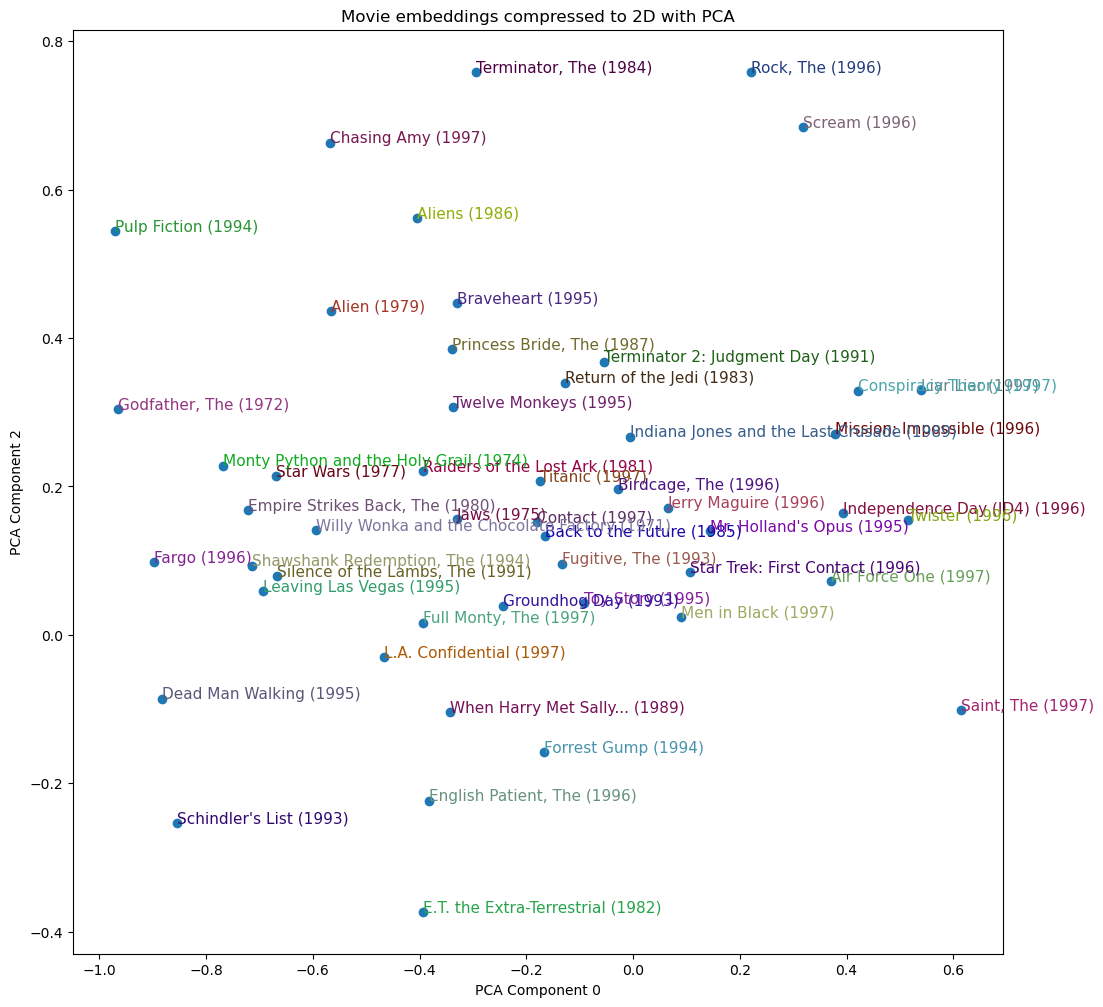

In [212]:
from torch import tensor
import matplotlib.pyplot as plt

# Step 1: Find the 1000 most-rated movies (filter out obscure ones)
g = ratings.groupby('title')['rating'].count()
top_movies = g.sort_values(ascending=False).index.values[:1000]

# Step 2: Grab their learned embedding vectors from the model
top_idxs = tensor([learn.dls.classes['title'].o2i[m] for m in top_movies])
movie_w = learn.model.movie_factors[top_idxs].cpu().detach()  # (1000, 50)

# Step 3: PCA compresses 50 dimensions → 3 principal components
movie_pca = movie_w.pca(3)
fac0, fac1, fac2 = movie_pca.t()  # unpack the 3 components

# Step 4: Plot the first 50 movies using component 0 (X) and component 2 (Y)
idxs = list(range(50))
X = fac0[idxs]
Y = fac2[idxs]
plt.figure(figsize=(12, 12))
plt.scatter(X, Y)
for i, x, y in zip(top_movies[idxs], X, Y):
    plt.text(x, y, i, color=np.random.rand(3)*0.7, fontsize=11)
plt.title('Movie embeddings compressed to 2D with PCA')
plt.xlabel('PCA Component 0')
plt.ylabel('PCA Component 2')
plt.show()

The model discovered structure from ratings alone — nobody told it about genres or critics. Movies that cluster together have similar embedding vectors, meaning similar users like them. You might see critically acclaimed films grouping separately from popular blockbusters, or classics separating from modern films.

📖 **Jargon:** No matter how many models I train, I never stop getting moved and surprised by how these randomly initialized bunches of numbers, trained with such simple mechanics, manage to discover things about my data all by themselves. It almost seems like cheating, that I can create code that does useful things without ever actually telling it how to do those things!

We defined our model from scratch to teach you what is inside, but you can directly use the fastai library to build it. We'll look at how to do that next.

### Using fastai.collab

We can create and train a collaborative filtering model using the exact structure shown earlier by using fastai's `collab_learner`:

In [213]:
# collab_learner builds the same DotProductBias model we wrote from scratch,
# but handles all the setup automatically
# n_factors=50: 50 latent factors, y_range=(0, 5.5): clamp predictions
learn = collab_learner(dls, n_factors=50, y_range=(0, 5.5))

In [214]:
# Same training as before: 5 epochs, lr=0.005, weight decay=0.1
learn.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time


The names of the layers can be seen by printing the model:

In [215]:
# Inspect the model structure — note fastai names the layers differently:
# i_weight = item (movie) factors, u_weight = user factors
# i_bias = item bias, u_bias = user bias
learn.model

EmbeddingDotBias(
  (u_weight): Embedding(944, 50)
  (i_weight): Embedding(1665, 50)
  (u_bias): Embedding(944, 1)
  (i_bias): Embedding(1665, 1)
)

We can use these to replicate any of the analyses we did in the previous section—for instance:

In [216]:
# Same bias analysis as before, but using fastai's attribute names
# i_bias = item (movie) bias layer, .weight = the actual parameter tensor
movie_bias = learn.model.i_bias.weight.squeeze()
idxs = movie_bias.argsort(descending=True)[:5]
[dls.classes['title'][i] for i in idxs]

['Shawshank Redemption, The (1994)',
 'As Good As It Gets (1997)',
 'L.A. Confidential (1997)',
 'Rear Window (1954)',
 "Schindler's List (1993)"]

So far we've used the trained model to **predict ratings** (dot product of user × movie). But the trained embeddings are useful on their own — we can measure **similarity between movies** directly. This is how "because you watched X" recommendations work.

### Embedding Distance

**Cosine similarity** measures whether two vectors point in the same direction, regardless of how long they are. Score of 1.0 = identical direction (very similar), 0 = unrelated, -1 = opposite.

Why not regular distance (Pythagoras)? An embedding of `[0.3, 0.8]` and `[0.6, 1.6]` represent the same taste profile at different magnitudes. Cosine correctly says "same taste." Euclidean distance would say "far apart," which is misleading.

This gives us a different kind of recommendation than the dot product approach:

- **"Top picks for you"** = dot your user embedding with every movie → rank by predicted rating. Uses your full taste profile. Might recommend a comedy even though you just watched a thriller.
- **"Because you watched X"** = cosine similarity between one movie and all others → rank by similarity. Stays in the same neighborhood as that specific film.

Let's find the most similar movie to *Silence of the Lambs*:

In [217]:
# Extract the learned movie embedding vectors
movie_factors = learn.model.i_weight.weight  # shape: (n_movies, 50)

# Find the index for Silence of the Lambs
# o2i = "object to index" mapping (title string → integer index)
idx = dls.classes['title'].o2i['Silence of the Lambs, The (1991)']

# Compute cosine similarity between Silence of the Lambs and ALL other movies
# movie_factors[idx][None] adds a batch dimension: (50,) → (1, 50) for broadcasting
# Result: one similarity score per movie, range [-1, 1]
distances = nn.CosineSimilarity(dim=1)(movie_factors, movie_factors[idx][None])

# Find the most similar movie (skip index 0 = itself, which has similarity 1.0)
idx = distances.argsort(descending=True)[1]
dls.classes['title'][idx]

'Some Folks Call It a Sling Blade (1993)'

We've trained a great model — but there's a fundamental problem we haven't addressed. What happens when someone new shows up?

## Bootstrapping a Collaborative Filtering Model

The biggest challenge with collaborative filtering in practice is the **cold start problem**. A new user has no ratings, so their embedding is random — the dot product with any movie is meaningless. Same for a brand new movie nobody has rated yet.

Think about it concretely. User 944 just signed up. Their embedding is `[0.003, -0.008, 0.001, ...]` — random noise. We dot that with every movie and get... random noise. Useless.

**Common solutions, from simplest to best:**

**1. Recommend popular items.** Not personalized, but safe. "Here are the 10 highest-rated movies" works as a starting point for everyone. This is why every streaming service has a "Trending Now" row.

**2. Use the average embedding.** Set the new user's embedding to the mean of all existing user embeddings. Problem: the "average user" might not represent any real taste — high sci-fi AND high romance AND high horror is nobody's actual profile.

**3. Ask onboarding questions.** "Rate these 5 movies" or "Pick genres you like." Netflix and Spotify do this at signup. Even 5-10 ratings give SGD enough signal to start adjusting the embedding away from random.

**4. Use metadata to predict an initial embedding.** If you know the user's age, country, and signup source, you can train a separate model that predicts what their embedding should be based on that metadata. This is the most sophisticated approach — it essentially uses content features to bootstrap the latent factors until real interaction data takes over.

In [218]:
# === The cold start problem in action ===

# Grab the trained embeddings and move to CPU for easy comparison
user_embs = learn.model.u_weight.weight.detach().cpu()    # (n_users, 50)
movie_embs = learn.model.i_weight.weight.detach().cpu()   # (n_movies, 50)
n_factors = movie_embs.shape[1]

# Pick an existing user — their embedding is well-trained after seeing many ratings
existing_user = user_embs[0]

# Simulate a NEW user — random embedding (what they'd start with before any ratings)
new_user = torch.randn(n_factors)  # already on CPU

# --- Existing user: top 5 movie recommendations ---
scores_existing = (movie_embs * existing_user).sum(dim=1)
top5_existing = scores_existing.argsort(descending=True)[:5]
print("Existing user — top 5 recommendations:")
for idx in top5_existing:
    print(f"  {dls.classes['title'][idx]:45s} score: {scores_existing[idx]:.2f}")

# --- New user: top 5 are random garbage ---
scores_new = (movie_embs * new_user).sum(dim=1)
top5_new = scores_new.argsort(descending=True)[:5]
print("\nNew user (random embedding) — top 5 recommendations:")
for idx in top5_new:
    print(f"  {dls.classes['title'][idx]:45s} score: {scores_new[idx]:.2f}")

# --- Fix: use average of all existing users as starting point ---
avg_user = user_embs.mean(dim=0)
scores_avg = (movie_embs * avg_user).sum(dim=1)
top5_avg = scores_avg.argsort(descending=True)[:5]
print("\nNew user (average embedding) — top 5 recommendations:")
for idx in top5_avg:
    print(f"  {dls.classes['title'][idx]:45s} score: {scores_avg[idx]:.2f}")
print("\n^ Not personalized, but at least recommends generally well-liked movies")

Existing user — top 5 recommendations:
  Evita (1996)                                  score: 0.01
  Deer Hunter, The (1978)                       score: 0.01
  Fantasia (1940)                               score: 0.00
  Graduate, The (1967)                          score: 0.00
  Scream (1996)                                 score: 0.00

New user (random embedding) — top 5 recommendations:
  Spawn (1997)                                  score: 3.98
  Leaving Las Vegas (1995)                      score: 3.54
  Shallow Grave (1994)                          score: 3.13
  Crash (1996)                                  score: 3.10
  Last Supper, The (1995)                       score: 3.10

New user (average embedding) — top 5 recommendations:
  Schindler's List (1993)                       score: 0.70
  Casablanca (1942)                             score: 0.69
  Shawshank Redemption, The (1994)              score: 0.68
  Some Folks Call It a Sling Blade (1993)       score: 0.65
  Close Shav

The random embedding produces nonsensical recommendations — obscure movies with high scores just because the random numbers happened to align. The average embedding at least gravitates toward broadly popular films, which is a reasonable default until the user starts rating things.

**A warning about feedback loops.** A small group of very active users can disproportionately steer the recommendations for everyone. Anime fans, for example, tend to rate heavily and watch narrowly — so collaborative filtering systems often over-recommend anime to new users.

This creates a self-reinforcing cycle: the system recommends anime → more anime fans join → the system recommends even more anime. The bias amplifies exponentially.

The fix: human oversight, careful monitoring, and diversity constraints in the recommendation pipeline. Assume feedback loops will happen and plan for them upfront.

Our dot product model works well and is the basis of many real-world recommendation systems (this approach is called *probabilistic matrix factorization*). But it has a limitation: the only thing it can use is user IDs and movie IDs. What if we also knew the movie's genre, release year, or the user's age?

The dot product model has no way to incorporate these extra features. To do that, we need to switch from a dot product to a neural network.

## Deep Learning for Collaborative Filtering

Instead of taking the dot product of the user and movie embeddings, what if we **concatenated** them into one big vector and fed it through a neural network? The key difference:

- **Dot product**: `user_emb · movie_emb → single number → prediction`. Simple, fast, but purely linear.
- **CollabNN**: `[user_emb, movie_emb] → Linear → ReLU → Linear → prediction`. Can learn nonlinear interactions.

For example, a dot product model can't learn "this user likes action AND comedy separately, but hates action-comedies." A neural network with ReLU can.

Since we're concatenating (not dotting), the user and movie embeddings don't need to be the same size. fastai's `get_emb_sz` recommends sizes based on the number of unique values:

In [219]:
# get_emb_sz returns recommended (num_categories, embedding_dim) for each categorical
# The embedding size is based on a rule of thumb: min(600, round(1.6 * n_cats^0.56))
embs = get_emb_sz(dls)
embs  # e.g. [(943, 74), (1664, 102)] — users get 74 factors, movies get 102

[(944, 74), (1665, 102)]

Let's implement this class:

In [220]:
class CollabNN(Module):
    def __init__(self, user_sz, item_sz, y_range=(0, 5.5), n_act=100):
        # Same embedding lookups as before
        self.user_factors = Embedding(*user_sz)    # e.g. (943, 74)
        self.item_factors = Embedding(*item_sz)     # e.g. (1664, 102)
        # NEW: a neural network that processes the concatenated embeddings
        self.layers = nn.Sequential(
            nn.Linear(user_sz[1] + item_sz[1], n_act),  # (74+102=176) → 100
            nn.ReLU(),                                     # nonlinearity!
            nn.Linear(n_act, 1))                           # 100 → 1 (predicted rating)
        self.y_range = y_range

    def forward(self, x):
        # Look up embeddings — same as DotProduct
        embs = self.user_factors(x[:, 0]), self.item_factors(x[:, 1])
        # DIFFERENT: concatenate the two vectors instead of dotting them
        # torch.cat joins them side by side: (batch, 74) + (batch, 102) → (batch, 176)
        x = self.layers(torch.cat(embs, dim=1))
        return sigmoid_range(x, *self.y_range)

And use it to create a model:

In [221]:
# *embs unpacks the list: CollabNN((943, 74), (1664, 102))
model = CollabNN(*embs)

`CollabNN` uses the same `Embedding` layers as before — the collaborative filtering still happens in those embeddings. The difference is what comes after: instead of dotting the two vectors, we concatenate them into one big vector `(74 + 102 = 176 numbers)` and pass it through a mini neural network `(Linear → ReLU → Linear)`.

During training, gradients flow backward through the linear layers **and into both embedding matrices**. Everything is trained together — one model, one loss, one `backward()`. The embeddings learn to be useful for whatever the neural network needs.

In [222]:
learn = Learner(dls, model, loss_func=MSELossFlat())
# Lower weight decay (0.01) — the neural net needs more freedom to learn
learn.fit_one_cycle(5, 5e-3, wd=0.01)

epoch,train_loss,valid_loss,time


fastai provides this model in `fastai.collab` if you pass `use_nn=True` in your call to `collab_learner` (including calling `get_emb_sz` for you), and it lets you easily create more layers. For instance, here we're creating two hidden layers, of size 100 and 50, respectively:

In [223]:
# fastai provides this as a one-liner with use_nn=True
# layers=[100, 50] means: Linear(176→100) → ReLU → Linear(100→50) → ReLU → Linear(50→1)
learn = collab_learner(dls, use_nn=True, y_range=(0, 5.5), layers=[100, 50])
learn.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time
0,0.993662,1.001530,00:03
1,0.906897,0.949784,00:03
2,0.836816,0.910623,00:03
3,0.750863,0.896978,00:02
4,0.742496,0.886599,00:03


`learn.model` is an object of type `EmbeddingNN`. Let's take a look at fastai's code for this class:

This is fastai's actual source code for `EmbeddingNN`:

```python
@delegates(TabularModel)
class EmbeddingNN(TabularModel):
    def __init__(self, emb_szs, layers, **kwargs):
        super().__init__(emb_szs, layers=layers, n_cont=0, out_sz=1, **kwargs)
```

This is the big reveal: `EmbeddingNN` is literally just `TabularModel` with `n_cont=0` (no continuous features) and `out_sz=1` (predict one number). Collaborative filtering was tabular ML all along — a table where all your columns are categorical (user ID, movie ID) with zero numeric features.

This means we could add continuous features too. Set `n_cont` to the number of numeric features you have, and now the model processes embeddings AND real numbers together through the same neural network.

### Sidebar: kwargs and Delegates

`EmbeddingNN` includes `**kwargs` as a parameter to `__init__`. In Python `**kwargs` in a parameter list means "put any additional keyword arguments into a dict called `kwargs`. And `**kwargs` in an argument list means "insert all key/value pairs in the `kwargs` dict as named arguments here". This approach is used in many popular libraries, such as `matplotlib`, in which the main `plot` function simply has the signature `plot(*args, **kwargs)`. The [`plot` documentation](https://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.plot) says "The `kwargs` are `Line2D` properties" and then lists those properties.

We're using `**kwargs` in `EmbeddingNN` to avoid having to write all the arguments to `TabularModel` a second time, and keep them in sync. However, this makes our API quite difficult to work with, because now Jupyter Notebook doesn't know what parameters are available. Consequently things like tab completion of parameter names and pop-up lists of signatures won't work.

fastai resolves this by providing a special `@delegates` decorator, which automatically changes the signature of the class or function (`EmbeddingNN` in this case) to insert all of its keyword arguments into the signature.

### End sidebar

**This is how production recommendation systems work.** The `EmbeddingNN` / `TabularModel` architecture lets you combine everything into one model:

- **Learned embeddings** for user ID, movie ID (the collaborative filtering signal — updated by SGD every batch)
- **Fixed features** from the dataset: genre, release year, user age, time of day, device type (these never change during training)

Both get concatenated and fed through the same neural network. The embeddings discover hidden taste patterns ("there's something about Wes Anderson films that appeals to Studio Ghibli fans"). The fixed features capture known structure ("action movies from the 90s"). Neither alone is complete — together they cover both.

The collaborative filtering IS the embeddings. Whether you dot them or feed them through a neural network, the same pattern emerges: similar users end up with similar vectors because that's what minimizes the loss.

## Conclusion

For our first non-computer vision application, we looked at recommendation systems and saw how gradient descent can learn intrinsic factors or biases about items from a history of ratings. Those can then give us information about the data. 

We also built our first model in PyTorch. We will do a lot more of this in the next section of the book, but first, let's finish our dive into the other general applications of deep learning, continuing with tabular data.

## Questionnaire

1. What problem does collaborative filtering solve?
1. How does it solve it?
1. Why might a collaborative filtering predictive model fail to be a very useful recommendation system?
1. What does a crosstab representation of collaborative filtering data look like?
1. Write the code to create a crosstab representation of the MovieLens data (you might need to do some web searching!).
1. What is a latent factor? Why is it "latent"?
1. What is a dot product? Calculate a dot product manually using pure Python with lists.
1. What does `pandas.DataFrame.merge` do?
1. What is an embedding matrix?
1. What is the relationship between an embedding and a matrix of one-hot-encoded vectors?
1. Why do we need `Embedding` if we could use one-hot-encoded vectors for the same thing?
1. What does an embedding contain before we start training (assuming we're not using a pretained model)?
1. Create a class (without peeking, if possible!) and use it.
1. What does `x[:,0]` return?
1. Rewrite the `DotProduct` class (without peeking, if possible!) and train a model with it.
1. What is a good loss function to use for MovieLens? Why? 
1. What would happen if we used cross-entropy loss with MovieLens? How would we need to change the model?
1. What is the use of bias in a dot product model?
1. What is another name for weight decay?
1. Write the equation for weight decay (without peeking!).
1. Write the equation for the gradient of weight decay. Why does it help reduce weights?
1. Why does reducing weights lead to better generalization?
1. What does `argsort` do in PyTorch?
1. Does sorting the movie biases give the same result as averaging overall movie ratings by movie? Why/why not?
1. How do you print the names and details of the layers in a model?
1. What is the "bootstrapping problem" in collaborative filtering?
1. How could you deal with the bootstrapping problem for new users? For new movies?
1. How can feedback loops impact collaborative filtering systems?
1. When using a neural network in collaborative filtering, why can we have different numbers of factors for movies and users?
1. Why is there an `nn.Sequential` in the `CollabNN` model?
1. What kind of model should we use if we want to add metadata about users and items, or information such as date and time, to a collaborative filtering model?

### Further Research

1. Take a look at all the differences between the `Embedding` version of `DotProductBias` and the `create_params` version, and try to understand why each of those changes is required. If you're not sure, try reverting each change to see what happens. (NB: even the type of brackets used in `forward` has changed!)
1. Find three other areas where collaborative filtering is being used, and find out what the pros and cons of this approach are in those areas.
1. Complete this notebook using the full MovieLens dataset, and compare your results to online benchmarks. See if you can improve your accuracy. Look on the book's website and the fast.ai forum for ideas. Note that there are more columns in the full dataset—see if you can use those too (the next chapter might give you ideas).
1. Create a model for MovieLens that works with cross-entropy loss, and compare it to the model in this chapter.

---

## Chapter 08 Questions & Answers

Click on each question to reveal the answer.

<details>
<summary><strong>1. What problem does collaborative filtering solve?</strong></summary>

Collaborative filtering solves the problem of predicting user interests and recommending items based on patterns in user behavior. It answers the question: "Which products/items are most likely to be useful for which users?"

**Key Applications:**
- Movie recommendations (Netflix)
- Product recommendations (Amazon)
- Content recommendations (YouTube, social media feeds)
- Music recommendations (Spotify, Pandora)

**How it works:** Look at what products the current user has used/liked, find other users with similar preferences, and recommend items those similar users enjoyed.

</details>

<details>
<summary><strong>2. How does it solve it?</strong></summary>

Collaborative filtering uses **latent factors** learned through gradient descent to identify hidden patterns in user preferences.

**Process:**
1. Initialize random embedding vectors for users and items
2. Calculate predictions using dot product of user/item embeddings
3. Compare predictions to actual ratings (compute loss)
4. Update embeddings via gradient descent
5. Repeat until model converges

**Example:**
```python
# User embedding: [sci-fi preference, action preference, age preference]
user = [0.9, 0.8, -0.6]  # Likes modern sci-fi action

# Movie embedding: [sci-fi score, action score, age score]
movie = [0.98, 0.9, -0.9]  # Modern sci-fi action film

# Prediction via dot product
rating = (user * movie).sum()  # = 2.14 (high rating predicted)
```

The model learns these latent factors **automatically** without being told what they represent.

</details>

<details>
<summary><strong>3. Why might collaborative filtering fail as a recommendation system?</strong></summary>

Collaborative filtering can fail when there is **insufficient data** about users or items:

| Problem | Description | Impact |
|---------|-------------|--------|
| **Cold Start (New Users)** | No history for new users | Cannot find similar users or make personalized recommendations |
| **Cold Start (New Items)** | No ratings for new products | Cannot recommend new items to anyone |
| **Sparse Data** | Users rated very few items | Difficult to find meaningful patterns |
| **Popularity Bias** | Small enthusiastic groups dominate | Over-representation of niche content (e.g., anime in movie rankings) |
| **Feedback Loops** | Recommendations reinforce existing biases | System increasingly serves narrow user segments |

**Example:** A brand new user signing up has zero rating history, so the system has no way to determine their preferences or find similar users.

</details>

<details>
<summary><strong>4. What does a crosstab representation look like?</strong></summary>

A crosstab (cross-tabulation) representation shows users as rows, items as columns, and ratings as cell values in a matrix:

```
              Movie 1  Movie 2  Movie 3  Movie 4
User 1           5        3        ?        4
User 2           ?        4        5        ?
User 3           3        ?        2        5
User 4           4        5        ?        3
```

**Characteristics:**
- Rows: Users
- Columns: Items (movies, products, etc.)
- Values: Ratings/interactions
- Empty cells (`?`): Missing ratings that the model should predict

**In practice:** Most cells are empty (sparse matrix) because users only rate a small fraction of available items.

</details>

<details>
<summary><strong>5. Write code for MovieLens crosstab</strong></summary>

Using pandas to create a crosstab from the MovieLens data:

```python
# Method 1: Using pivot_table
crosstab = ratings.pivot_table(
    index='user',
    columns='title',
    values='rating'
)

# Method 2: Using crosstab
crosstab = pd.crosstab(
    index=ratings['user'],
    columns=ratings['title'],
    values=ratings['rating'],
    aggfunc='mean'  # Average rating if multiple ratings exist
)

# View a sample
print(crosstab.iloc[:10, :10])
```

**Sample output:**
```
title                Toy Story  GoldenEye  Four Rooms  ...
user
1                          5.0        NaN         NaN  ...
2                          NaN        4.0         NaN  ...
3                          NaN        NaN         3.0  ...
```

NaN values represent missing ratings that collaborative filtering aims to predict.

</details>

<details>
<summary><strong>6. What is a latent factor and why "latent"?</strong></summary>

A **latent factor** is a hidden characteristic that influences user preferences but is not explicitly provided in the data.

**Why "latent" (hidden)?** Not directly observable, not labeled by humans, discovered automatically by the model through training.

**Examples in movies:** Genre preferences (sci-fi, romance), era preferences (classic vs. modern), director/actor preferences, tone preferences.

```python
# Movie latent factors (learned, not specified)
# Factors might represent: [sci-fi, action, old, indie, quality]
star_wars = [0.98, 0.9, -0.9, -0.8, 0.85]
casablanca = [-0.99, -0.3, 0.8, 0.7, 0.9]
```

</details>

<details>
<summary><strong>7. What is a dot product?</strong></summary>

A **dot product** multiplies corresponding elements of two vectors and sums the results.

**Formula:** For vectors `a` and `b`: `a · b = a₁×b₁ + a₂×b₂ + ... + aₙ×bₙ`

**Pure Python implementation:**
```python
def dot_product(a, b):
    return sum(x * y for x, y in zip(a, b))

# Example
user = [0.9, 0.8, -0.6]
movie = [0.98, 0.9, -0.9]
result = dot_product(user, movie)
# = 0.882 + 0.72 + 0.54 = 2.142
```

**In collaborative filtering:** High dot product → user likely to enjoy the item.

</details>

<details>
<summary><strong>8. What does pandas.DataFrame.merge do?</strong></summary>

`merge()` combines multiple DataFrames based on common columns (similar to SQL JOIN).

```python
# MovieLens example
ratings = pd.read_csv('u.data', delimiter='\t', header=None,
                      names=['user', 'movie', 'rating', 'timestamp'])
movies = pd.read_csv('u.item', delimiter='|', encoding='latin-1',
                     usecols=(0,1), names=('movie', 'title'), header=None)

# Merge to get titles with ratings
ratings = ratings.merge(movies)
```

**Merge types:** `inner` (default), `left`, `right`, `outer` - similar to SQL joins.

</details>

<details>
<summary><strong>9. What is an embedding matrix?</strong></summary>

An **embedding matrix** is a learned lookup table that maps discrete entities to continuous vector representations.

**Structure:**
```
         Factor 1  Factor 2  Factor 3  ... Factor N
Item 1     0.23     -0.45      0.78   ...   0.12
Item 2    -0.67      0.34     -0.23   ...   0.89
```

**Example:**
```python
import torch.nn as nn
movie_embedding = nn.Embedding(num_embeddings=1000, embedding_dim=50)
movie_id = torch.tensor([42])
movie_vector = movie_embedding(movie_id)  # Returns tensor of shape (1, 50)
```

Initially random, becomes meaningful through training.

</details>

<details>
<summary><strong>10. Relationship between embedding and one-hot vectors?</strong></summary>

An embedding is mathematically equivalent to multiplying by a one-hot encoded matrix, but much more efficient.

```python
# One-hot: [0, 0, 0, 1, 0] × embedding_matrix = item_3_vector
# Embedding: embedding_matrix[3] = item_3_vector (same result!)
```

**Comparison:** One-hot requires O(n) memory and O(n×d) computation; embedding requires O(1) for both.

</details>

<details>
<summary><strong>11. Why use Embedding over one-hot vectors?</strong></summary>

Embedding layers are dramatically more efficient:
- **Memory:** Store single integer index vs. full n-dimensional vector
- **Computation:** Array indexing O(1) vs. matrix multiplication O(n×d)
- **Gradients:** Identical results

Critical when vocabulary size is large (e.g., 10,000+ items).

</details>

<details>
<summary><strong>12. What does embedding contain before training?</strong></summary>

**Randomly initialized values**, typically from a normal distribution N(0, 1).

```python
embedding = nn.Embedding(1000, 50)
print(embedding.weight[0])  # Random values, no semantic meaning yet
```

During training, these values become meaningful representations.

</details>

<details>
<summary><strong>13. Create and use a class</strong></summary>

```python
class MovieRecommender:
    def __init__(self, user_name, favorite_genre):
        self.user_name = user_name
        self.favorite_genre = favorite_genre
        self.watched_movies = []

    def add_movie(self, movie_title):
        self.watched_movies.append(movie_title)

    def summary(self):
        return f"{self.user_name} likes {self.favorite_genre}"

# Usage
user = MovieRecommender('Alice', 'sci-fi')
user.add_movie('Interstellar')
print(user.summary())
```

</details>

<details>
<summary><strong>14. What does x[:,0] return?</strong></summary>

Returns the **first column** of a 2D array/tensor (all rows, column 0).

```python
x = torch.tensor([[196, 242], [186, 302], [22, 377]])
user_ids = x[:, 0]   # tensor([196, 186, 22]) - all user IDs
movie_ids = x[:, 1]  # tensor([242, 302, 377]) - all movie IDs
```

</details>

<details>
<summary><strong>15. Rewrite DotProduct class</strong></summary>

```python
class DotProduct(Module):
    def __init__(self, n_users, n_movies, n_factors, y_range=(0, 5.5)):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.movie_factors = nn.Embedding(n_movies, n_factors)
        self.y_range = y_range

    def forward(self, x):
        users = self.user_factors(x[:, 0])
        movies = self.movie_factors(x[:, 1])
        dot_product = (users * movies).sum(dim=1)
        return sigmoid_range(dot_product, *self.y_range)
```

</details>

<details>
<summary><strong>16. Good loss function for MovieLens? Why?</strong></summary>

**Mean Squared Error (MSE)** - ratings are continuous numerical values (0.5 to 5.0).

```python
from fastai.losses import MSELossFlat
learn = Learner(dls, model, loss_func=MSELossFlat())
```

MSE measures how far predictions are from actual ratings and penalizes larger errors more heavily. Standard choice for regression.

</details>

<details>
<summary><strong>17. Using CrossEntropy loss?</strong></summary>

Must treat ratings as discrete classes. Required changes:
1. Convert ratings to class indices (0.5→0, 1.0→1, ..., 5.0→9)
2. Change model output to produce n_classes predictions instead of 1
3. Use `nn.CrossEntropyLoss()`

```python
# Output layer produces class scores
self.output = nn.Linear(n_factors, n_classes)  # n_classes=10
```

In practice, MSE works better for continuous ratings.

</details>

<details>
<summary><strong>18. Use of bias in dot product model?</strong></summary>

Bias captures intrinsic quality not represented by latent factors:
- **Movie bias:** Some movies are universally better/worse
- **User bias:** Some users rate everything higher/lower

```python
rating = user_factors · movie_factors + user_bias + movie_bias
```

This allows the model to represent "Is this movie good?" and "Is this user generous?" independently from genre matching.

</details>

<details>
<summary><strong>19. Another name for weight decay?</strong></summary>

**L2 Regularization** (also Ridge Regression in classical statistics).

Both terms refer to adding the sum of squared weights to the loss function.

</details>

<details>
<summary><strong>20. Equation for weight decay</strong></summary>

```
loss_with_wd = loss + wd × Σ(parameters²)
```

Where `wd` is the weight decay coefficient and `Σ(parameters²)` is the sum of all squared weights.

Efficient implementation adds to gradients:
```python
parameters.grad += wd × parameters
```

</details>

<details>
<summary><strong>21. Gradient of weight decay. Why reduce weights?</strong></summary>

Gradient: `∂(loss_with_wd)/∂parameters = ∂loss/∂parameters + wd × parameters`

Each update: `parameters = parameters × (1 - lr × wd) - lr × gradients`

The term `(1 - lr × wd)` < 1 causes multiplicative shrinkage, decaying weights toward zero. This prevents overfitting by keeping weights small.

</details>

<details>
<summary><strong>22. Why reducing weights improves generalization?</strong></summary>

Small weights create smoother, simpler decision boundaries that generalize better. Large weights create sharp, narrow valleys that overfit to training data noise.

**Analogy:** Understanding concepts (small weights) vs. memorizing specific examples (large weights).

</details>

<details>
<summary><strong>23. What does argsort do?</strong></summary>

Returns the **indices** that would sort an array.

```python
values = torch.tensor([30, 10, 40, 20])
indices = values.argsort()  # tensor([1, 3, 0, 2])
# values[1]=10, values[3]=20, values[0]=30, values[2]=40

# Get sorted values
sorted_values = values[indices]  # tensor([10, 20, 30, 40])
```

Useful for finding top-k items or retrieving associated data for sorted values.

</details>

<details>
<summary><strong>24. Movie bias vs. average ratings?</strong></summary>

**No**, movie bias ≠ average ratings. Bias captures quality **after accounting for** user tendencies and genre matching.

**Movie bias:** "How much do people like this movie beyond what we'd expect from their preferences?"

A movie with high average rating from niche fans might have low bias. A movie loved even by people who shouldn't like it has high bias.

</details>

<details>
<summary><strong>25. Print model layer names?</strong></summary>

Simply type the model object:

```python
learn.model
# or
print(learn.model)
```

For more details:
```python
for name, layer in learn.model.named_children():
    print(f"{name}: {layer}")
```

</details>

<details>
<summary><strong>26. Bootstrapping problem?</strong></summary>

The **bootstrapping problem** occurs when collaborative filtering cannot make recommendations due to lack of data:
- **New users:** No rating history → cannot find similar users
- **New items:** No ratings → cannot recommend to anyone

The system needs initial data to start making useful recommendations.

</details>

<details>
<summary><strong>27. Deal with bootstrapping for new users/movies?</strong></summary>

**For new users:**
1. Use average embeddings
2. Onboarding questionnaire → tabular model
3. Show popular items initially
4. Update embedding as user rates items

**For new movies:**
1. Use metadata-based similarity
2. Content-based initialization
3. Expert curation (copy similar movie embedding)
4. Promote to targeted users

**Best practice:** Hybrid approach combining multiple strategies.

</details>

<details>
<summary><strong>28. Impact of feedback loops?</strong></summary>

Feedback loops create self-reinforcing cycles that amplify biases:

```
Recommend items → Users interact → Model updates →
Recommends similar items MORE → Cycle repeats → Exponential amplification
```

**Examples:**
- Small enthusiastic groups dominate recommendations
- Popular items become more popular
- Filter bubbles form
- System behavior shifts unexpectedly

**Mitigation:** Monitor diversity, inject randomness, debias training data, promote new content, humans in the loop.

</details>

<details>
<summary><strong>29. Different factors for users/movies in neural networks?</strong></summary>

Neural networks can have different embedding sizes because they **concatenate** embeddings rather than computing dot products.

```python
users = self.user_factors(x[:, 0])   # Shape: (batch, 50)
movies = self.movie_factors(x[:, 1]) # Shape: (batch, 100) - different!
combined = torch.cat([users, movies], dim=1)  # Shape: (batch, 150)
self.layers(combined)  # Linear layer handles concatenated input
```

Dot product requires same size; concatenation is flexible.

</details>

<details>
<summary><strong>30. Why nn.Sequential in CollabNN?</strong></summary>

`nn.Sequential` couples multiple layers into a single pipeline for cleaner code:

```python
# Instead of calling each layer manually:
x = self.linear1(x)
x = self.relu1(x)
x = self.linear2(x)

# Use Sequential:
self.layers = nn.Sequential(nn.Linear(...), nn.ReLU(), nn.Linear(...))
x = self.layers(x)  # One call executes entire pipeline
```

Benefits: cleaner code, easier to modify, automatic parameter registration.

</details>

<details>
<summary><strong>31. Model for metadata integration?</strong></summary>

Use a **Tabular Model** to integrate metadata about users/items or contextual information.

```python
from fastai.tabular.all import *

dls = TabularDataLoaders.from_df(
    df,
    cat_names=['user', 'movie', 'genre', 'day_of_week'],
    cont_names=['user_age', 'movie_year', 'hour_of_day'],
    y_names='rating',
    y_block=RegressionBlock()
)

learn = tabular_learner(dls, layers=[200, 100], metrics=rmse)
```

TabularModel handles categorical embeddings, continuous normalization, and combines everything for rich recommendations.

</details>

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>